In [19]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [20]:
# %% Cellule 1 : Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import json
import joblib
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import MultiLabelBinarizer, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, top_k_accuracy_score,
    confusion_matrix, ndcg_score
)
from sklearn.calibration import CalibratedClassifierCV
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

print("Imports réussis.")

Imports réussis.


Cellule 2 : Chargement des données

In [21]:
# %% Cellule 2 : Chargement des données
FILE_PATH = "/content/drive/MyDrive/ISPM/ISPM - M2 ML/Clinique/donnees_synthetiques_finales_CORRIGE.csv"

try:
    df = pd.read_csv(FILE_PATH, encoding='utf-8-sig', sep=',', quotechar='"')
except Exception as e:
    print(f"Erreur avec sep=',' : {e}")
    try:
        df = pd.read_csv(FILE_PATH, encoding='utf-8-sig', sep=';', quotechar='"')
    except Exception as e2:
        print(f"Erreur avec sep=';' : {e2}")
        df = pd.read_csv(FILE_PATH, encoding='utf-8-sig', sep=',', quotechar='"', on_bad_lines='skip')
        print("Lecture effectuée en sautant les lignes mal formées.")

print(f"Dataset : {df.shape}")
print(df.head())

Dataset : (1000, 18)
            Horodateur Vous êtes actuellement :  \
0  2026-07-11 11:56:10        Professionnel(le)   
1  2026-08-01 10:35:24              Étudiant(e)   
2  2026-08-21 07:03:56        Professionnel(le)   
3  2026-08-14 13:24:40              Étudiant(e)   
4  2026-08-13 17:59:22              Étudiant(e)   

  Quelle était votre série au Baccalauréat ?  \
0                                          G   
1                                          S   
2                                         A2   
3                                          S   
4                                         A2   

  Quelles étaient vos matières préférées au lycée ?  \
0                           Économie; Mathématiques   
1                           Mathématiques; Économie   
2                 Mathématiques; Économie; Français   
3                             Informatique; Anglais   
4                                Économie; Français   

  Dans quelles matières vous étiez doués?  \
0      

Cellule 3 : Suppression de la colonne métier et définition de la target

In [22]:
# %% Cellule 3 : Suppression métier et définition de la target
COL_METIER = "Si vous êtes diplômé(e) / professionnel(le), quel est votre métier actuel ?"
if COL_METIER in df.columns:
    df.drop(columns=[COL_METIER], inplace=True)

target_col = "si vous devenez etudiant à l'ISPM, quel filière choisiriez vous?"

def extract_acronym(name):
    if not isinstance(name, str):
        return name
    match = re.search(r'\b([A-Z]{3,})(?:\s*:|$)', name)
    return match.group(1) if match else name.strip()

def clean_filiere(series):
    series = series.str.strip().str.replace(r'\s+', ' ', regex=True)
    return series.apply(extract_acronym)

df[target_col] = clean_filiere(df[target_col])

print("Classes dans le dataset :", sorted(df[target_col].unique()))

Classes dans le dataset : ['AEE', 'CAA', 'DTJA', 'EMII', 'EMP', 'ESIIA', 'FIC', 'GCA', 'IAA', 'ICMP', 'IGGLIA', 'IMTICIA', 'ISAIA', 'PIP', 'TEE', 'TEH']


Cellule 4 : Suppression métier et définition de la target

In [23]:
# %% Cellule 4 : Définition des features
col_interets = "Quels sont vos domaines d'intérêt principaux ?"
col_travail = "Préférez-vous travailler principalement"

FEATURE_COLS = [
    'Quelle était votre série au Baccalauréat ?',
    'Quelles étaient vos matières préférées au lycée ?',
    'Dans quelles matières vous étiez doués?',
    'Dans quelles activités pensez-vous être naturellement à l\'aise ?',
    'Parmi les activités suivantes, lesquelles vous attirent le plus ?',
    'Quel type de problème aimez-vous le plus résoudre ?',
    'Quel type d\'activité pédagogique vous attire le plus ?',
    'Aimez-vous plutôt la pratique ou les leçons (théorie) ?',
    'Quel rythme de travail vous correspond le mieux ?',
    'Dans quel environnement aimeriez-vous travailler ?',
    col_interets,
    col_travail,
    'Qu\'est-ce qui est le plus important pour vous dans le choix d\'une formation ?'
]

missing = [c for c in FEATURE_COLS if c not in df.columns]
if missing:
    print(f"Colonnes manquantes : {missing}")
else:
    print("Toutes les colonnes sont présentes.")

Toutes les colonnes sont présentes.


Cellule 5 : Filtrage des classes rares

In [24]:
# %% Cellule 5 : Filtrage des classes rares
min_samples = 2
class_counts = df[target_col].value_counts()
classes_to_keep = class_counts[class_counts >= min_samples].index

df_filtered = df[df[target_col].isin(classes_to_keep)].copy()
print(f"Dataset filtré : {len(df_filtered)} lignes, {len(classes_to_keep)} classes")
print("Classes conservées :", sorted(classes_to_keep))

Dataset filtré : 1000 lignes, 16 classes
Classes conservées : ['AEE', 'CAA', 'DTJA', 'EMII', 'EMP', 'ESIIA', 'FIC', 'GCA', 'IAA', 'ICMP', 'IGGLIA', 'IMTICIA', 'ISAIA', 'PIP', 'TEE', 'TEH']


Cellule 6 : Split train/validation/test (80/10/10)

In [25]:
# %% Cellule 6 : Split train/validation/test (80/10/10)
X_df = df_filtered[FEATURE_COLS].copy()
y = df_filtered[target_col].copy()

X_train, X_temp, y_train, y_temp = train_test_split(
    X_df, y, test_size=0.2, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"Train : {X_train.shape[0]} échantillons")
print(f"Val   : {X_val.shape[0]} échantillons")
print(f"Test  : {X_test.shape[0]} échantillons")

Train : 800 échantillons
Val   : 100 échantillons
Test  : 100 échantillons


Cellule 7 : Fonctions d'encodage multi-label

In [26]:
# %% Cellule 7 : Fonctions d'encodage
def split_and_clean(series, sep=';'):
    return series.fillna('').apply(lambda x: [item.strip() for item in str(x).split(sep) if item.strip() != ''])

def encode_multilabel(df, columns, encoders=None, fit=True):
    if encoders is None:
        encoders = {}
    encoded_parts = []
    for col in columns:
        if col not in df.columns:
            df[col] = ''
        lists = split_and_clean(df[col])
        if col in encoders and not fit:
            mlb = encoders[col]
            encoded = mlb.transform(lists)
        else:
            mlb = MultiLabelBinarizer()
            encoded = mlb.fit_transform(lists)
            encoders[col] = mlb
        col_names = [f"{col}_{cls}" for cls in mlb.classes_]
        enc_df = pd.DataFrame(encoded, columns=col_names, index=df.index)
        encoded_parts.append(enc_df)
    X_encoded = pd.concat(encoded_parts, axis=1).fillna(0)
    return X_encoded, encoders

Cellule 8 : Encodage des données

In [27]:
# %% Cellule 8 : Encodage des données
encoders = {}
X_train_enc, encoders = encode_multilabel(X_train, FEATURE_COLS, encoders, fit=True)
X_val_enc, _ = encode_multilabel(X_val, FEATURE_COLS, encoders, fit=False)
X_test_enc, _ = encode_multilabel(X_test, FEATURE_COLS, encoders, fit=False)

print(f"Train encodé : {X_train_enc.shape}")
print(f"Val encodé   : {X_val_enc.shape}")
print(f"Test encodé  : {X_test_enc.shape}")

Train encodé : (800, 175)
Val encodé   : (100, 175)
Test encodé  : (100, 175)


Cellule 9 : Normalisation

In [28]:
# %% Cellule 9 : Normalisation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_enc)
X_val_scaled = scaler.transform(X_val_enc)
X_test_scaled = scaler.transform(X_test_enc)

print("Normalisation appliquée.")

Normalisation appliquée.


Cellule 10 : Entraînement et sélection du meilleur modèle

In [30]:
# %% Cellule 10 : Entraînement des trois modèles et sélection

from sklearn.preprocessing import LabelEncoder

# 1) Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42, multi_class='multinomial')
param_lr = {'C': [0.1, 1, 10]}
grid_lr = GridSearchCV(lr, param_lr, cv=5, scoring='f1_macro', n_jobs=-1)
grid_lr.fit(X_train_scaled, y_train)
best_lr = grid_lr.best_estimator_
print("Logistic Regression - meilleurs params :", grid_lr.best_params_)
print("F1-macro moyen (CV) :", grid_lr.best_score_)

# 2) Random Forest
rf = RandomForestClassifier(random_state=42, n_jobs=-1)
param_rf = {'n_estimators': [100, 200], 'max_depth': [10, 20, None]}
grid_rf = GridSearchCV(rf, param_rf, cv=5, scoring='f1_macro', n_jobs=-1)
grid_rf.fit(X_train_scaled, y_train)
best_rf = grid_rf.best_estimator_
print("\nRandom Forest - meilleurs params :", grid_rf.best_params_)
print("F1-macro moyen (CV) :", grid_rf.best_score_)

# 3) XGBoost (avec encodage des labels)
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_val_enc = le.transform(y_val)
y_test_enc = le.transform(y_test)

xgb = XGBClassifier(random_state=42, n_jobs=-1, use_label_encoder=False, eval_metric='mlogloss')
param_xgb = {'n_estimators': [100, 200], 'max_depth': [6, 10], 'learning_rate': [0.1, 0.3]}
grid_xgb = GridSearchCV(xgb, param_xgb, cv=5, scoring='f1_macro', n_jobs=-1)
grid_xgb.fit(X_train_scaled, y_train_enc)
best_xgb = grid_xgb.best_estimator_
print("\nXGBoost - meilleurs params :", grid_xgb.best_params_)
print("F1-macro moyen (CV) :", grid_xgb.best_score_)

# Évaluation sur validation
y_pred_lr = best_lr.predict(X_val_scaled)
y_pred_rf = best_rf.predict(X_val_scaled)
y_pred_xgb_enc = best_xgb.predict(X_val_scaled)
y_pred_xgb = le.inverse_transform(y_pred_xgb_enc)  # décodage

f1_lr = f1_score(y_val, y_pred_lr, average='macro')
f1_rf = f1_score(y_val, y_pred_rf, average='macro')
f1_xgb = f1_score(y_val, y_pred_xgb, average='macro')

print(f"\nF1-macro (Val) - Logistic Regression : {f1_lr:.4f}")
print(f"F1-macro (Val) - Random Forest      : {f1_rf:.4f}")
print(f"F1-macro (Val) - XGBoost            : {f1_xgb:.4f}")

# Sélection du meilleur modèle
scores = {'LogisticRegression': f1_lr, 'RandomForest': f1_rf, 'XGBoost': f1_xgb}
best_name = max(scores, key=scores.get)

if best_name == 'XGBoost':
    best_model = best_xgb
    best_cv_score = grid_xgb.best_score_
    # On garde le LabelEncoder pour l'inférence
    label_encoder = le
else:
    best_model = best_lr if best_name == 'LogisticRegression' else best_rf
    best_cv_score = grid_lr.best_score_ if best_name == 'LogisticRegression' else grid_rf.best_score_
    label_encoder = None  # pas nécessaire

model_name = best_name
print(f"\nModèle sélectionné : {model_name} avec F1-val = {scores[best_name]:.4f}")

Logistic Regression - meilleurs params : {'C': 0.1}
F1-macro moyen (CV) : 0.5458419973596647

Random Forest - meilleurs params : {'max_depth': None, 'n_estimators': 200}
F1-macro moyen (CV) : 0.5170324502094005

XGBoost - meilleurs params : {'learning_rate': 0.3, 'max_depth': 6, 'n_estimators': 100}
F1-macro moyen (CV) : 0.5638438470461875

F1-macro (Val) - Logistic Regression : 0.5832
F1-macro (Val) - Random Forest      : 0.4723
F1-macro (Val) - XGBoost            : 0.5284

Modèle sélectionné : LogisticRegression avec F1-val = 0.5832


Cellule 11 : Sauvegarde des artefacts

In [31]:
# %% Cellule 11 : Sauvegarde des artefacts
joblib.dump(best_model, 'model.pkl')
joblib.dump(encoders, 'encoders.pkl')
joblib.dump(scaler, 'scaler.pkl')
if label_encoder is not None:
    joblib.dump(label_encoder, 'label_encoder.pkl')

metadata = {
    "model": model_name,
    "features": FEATURE_COLS,
    "classes": list(best_model.classes_) if hasattr(best_model, 'classes_') else list(le.classes_),
    "f1_score_val": scores[best_name],
    "cv_score": best_cv_score,
    "date": str(pd.Timestamp.now())
}
with open('metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("Modèle, encodeurs, scaler et métadonnées sauvegardés.")

Modèle, encodeurs, scaler et métadonnées sauvegardés.


Cellule 12 : Évaluation sur le test

=== Évaluation sur le test ===
accuracy        : 0.5900
top3_accuracy   : 0.8900
top5_accuracy   : 0.9900
f1_macro        : 0.5923
mrr             : 0.7468
ndcg@5          : 0.8071


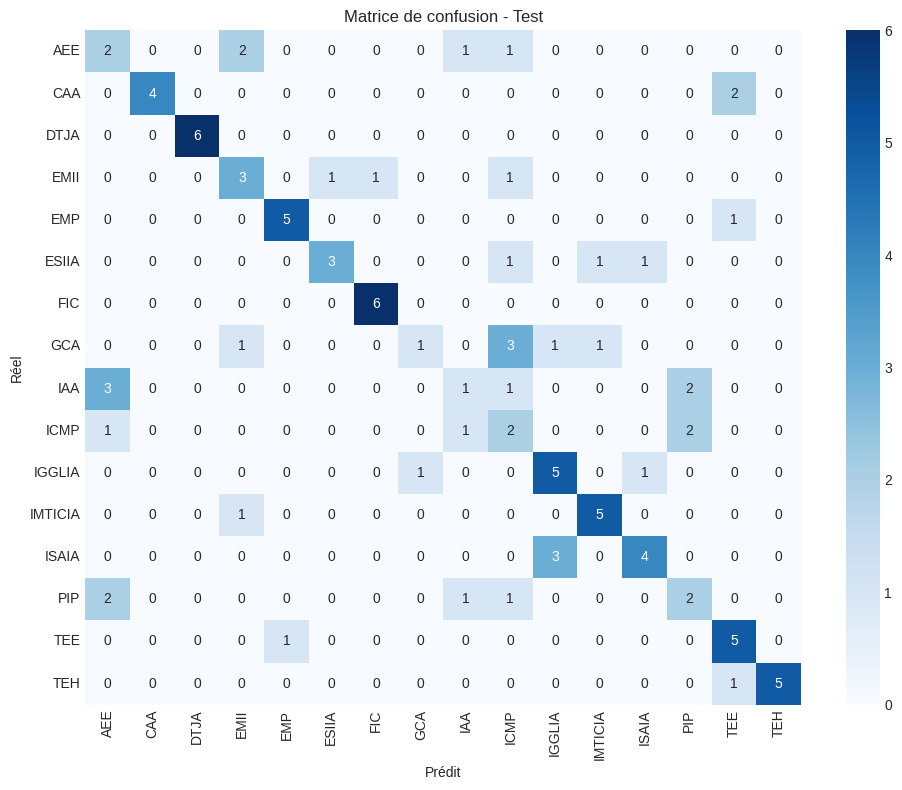

In [32]:
# %% Cellule 12 : Évaluation sur le test

if model_name == 'XGBoost':
    # On utilise les labels encodés pour les prédictions, puis on décode
    y_pred_test_enc = best_model.predict(X_test_scaled)
    y_pred_test = label_encoder.inverse_transform(y_pred_test_enc)
    y_proba_test = best_model.predict_proba(X_test_scaled)
    # Pour les métriques comme top_k_accuracy, on doit utiliser les labels encodés
    # car il faut que y_true et y_score aient les mêmes classes.
    # On va donc utiliser y_test_enc pour ces métriques, puis décoder pour l'affichage.
    y_test_enc = label_encoder.transform(y_test)
    acc = accuracy_score(y_test_enc, y_pred_test_enc)
    top3 = top_k_accuracy_score(y_test_enc, y_proba_test, k=3, labels=best_model.classes_)
    top5 = top_k_accuracy_score(y_test_enc, y_proba_test, k=5, labels=best_model.classes_)
    f1 = f1_score(y_test_enc, y_pred_test_enc, average='macro')
    # MRR et NDCG utilisent les probas et les labels encodés
    mrr = 0.0
    for i, true_label in enumerate(y_test_enc):
        probas = y_proba_test[i]
        sorted_idx = np.argsort(probas)[::-1]
        rank = np.where(sorted_idx == true_label)[0]
        if len(rank) > 0:
            mrr += 1.0 / (rank[0] + 1)
    mrr /= len(y_test_enc)
    y_true_bin = np.zeros((len(y_test_enc), len(best_model.classes_)))
    for i, label in enumerate(y_test_enc):
        y_true_bin[i, label] = 1
    ndcg5 = ndcg_score(y_true_bin, y_proba_test, k=5)
else:
    # Pour LR et RF, on utilise les labels originaux
    y_pred_test = best_model.predict(X_test_scaled)
    y_proba_test = best_model.predict_proba(X_test_scaled)
    acc = accuracy_score(y_test, y_pred_test)
    top3 = top_k_accuracy_score(y_test, y_proba_test, k=3, labels=best_model.classes_)
    top5 = top_k_accuracy_score(y_test, y_proba_test, k=5, labels=best_model.classes_)
    f1 = f1_score(y_test, y_pred_test, average='macro')
    # MRR
    mrr = 0.0
    for i, true_label in enumerate(y_test):
        probas = y_proba_test[i]
        classes = best_model.classes_
        sorted_idx = np.argsort(probas)[::-1]
        rank = np.where(classes[sorted_idx] == true_label)[0]
        if len(rank) > 0:
            mrr += 1.0 / (rank[0] + 1)
    mrr /= len(y_test)
    # NDCG@5
    y_true_bin = np.zeros((len(y_test), len(best_model.classes_)))
    for i, label in enumerate(y_test):
        if label in best_model.classes_:
            y_true_bin[i, list(best_model.classes_).index(label)] = 1
    ndcg5 = ndcg_score(y_true_bin, y_proba_test, k=5)

results_test = {
    "accuracy": acc,
    "top3_accuracy": top3,
    "top5_accuracy": top5,
    "f1_macro": f1,
    "mrr": mrr,
    "ndcg@5": ndcg5
}

print("=== Évaluation sur le test ===")
for k, v in results_test.items():
    print(f"{k:15} : {v:.4f}")

# Matrice de confusion (avec les labels originaux pour lisibilité)
if model_name == 'XGBoost':
    y_pred_decoded = label_encoder.inverse_transform(y_pred_test_enc)
    y_test_decoded = y_test
    classes_real = sorted(set(y_test_decoded) & set(label_encoder.classes_))
    cm = confusion_matrix(y_test_decoded, y_pred_decoded, labels=classes_real)
else:
    y_pred_decoded = y_pred_test
    y_test_decoded = y_test
    classes_real = sorted(set(y_test_decoded) & set(best_model.classes_))
    cm = confusion_matrix(y_test_decoded, y_pred_decoded, labels=classes_real)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes_real, yticklabels=classes_real)
plt.title("Matrice de confusion - Test")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.tight_layout()
plt.show()

Cellule 13 : Analyse des erreurs

In [33]:
# %% Cellule 13 : Analyse des erreurs
errors = y_test != y_pred_test
error_indices = np.where(errors)[0]
print(f"Nombre d'erreurs : {len(error_indices)} / {len(y_test)}")

if len(error_indices) > 0:
    print("\nDétail des erreurs (vraie vs prédite) :")
    for idx in error_indices[:10]:
        true_label = y_test.iloc[idx]
        pred_label = y_pred_test[idx]
        probas = y_proba_test[idx]
        top3_classes = [best_model.classes_[i] for i in np.argsort(probas)[::-1][:3]]
        print(f"Vraie: {true_label:15} | Prédite: {pred_label:15} | Top-3: {top3_classes}")

    error_classes = y_test.iloc[error_indices].value_counts()
    print("\nClasses les plus souvent mal prédites :")
    print(error_classes)

Nombre d'erreurs : 41 / 100

Détail des erreurs (vraie vs prédite) :
Vraie: AEE             | Prédite: ICMP            | Top-3: ['ICMP', 'PIP', 'IAA']
Vraie: ESIIA           | Prédite: ISAIA           | Top-3: ['ISAIA', 'ESIIA', 'IMTICIA']
Vraie: IAA             | Prédite: AEE             | Top-3: ['AEE', 'PIP', 'CAA']
Vraie: ICMP            | Prédite: IAA             | Top-3: ['IAA', 'ICMP', 'GCA']
Vraie: ESIIA           | Prédite: IMTICIA         | Top-3: ['IMTICIA', 'EMII', 'ESIIA']
Vraie: GCA             | Prédite: IMTICIA         | Top-3: ['IMTICIA', 'ESIIA', 'GCA']
Vraie: CAA             | Prédite: TEE             | Top-3: ['TEE', 'CAA', 'IAA']
Vraie: ICMP            | Prédite: PIP             | Top-3: ['PIP', 'ICMP', 'IAA']
Vraie: TEE             | Prédite: EMP             | Top-3: ['EMP', 'TEE', 'CAA']
Vraie: CAA             | Prédite: TEE             | Top-3: ['TEE', 'CAA', 'PIP']

Classes les plus souvent mal prédites :
si vous devenez etudiant à l'ISPM, quel filière choisiri

Cellule 14 : Fonctions d'inférence pour l'assistant

In [34]:
# %% Cellule 14 : Fonctions d'inférence pour l'assistant

# Charger le label encoder si XGBoost
if model_name == 'XGBoost':
    label_encoder = joblib.load('label_encoder.pkl')
else:
    label_encoder = None

def analyser_profil(profil_dict, model=best_model, encoders=encoders,
                    scaler=scaler, feature_cols=FEATURE_COLS, top_k=5,
                    label_encoder=label_encoder):
    df_profil = pd.DataFrame([profil_dict])
    for col in feature_cols:
        if col not in df_profil.columns:
            df_profil[col] = ''

    X_enc, _ = encode_multilabel(df_profil, feature_cols, encoders, fit=False)
    X_scaled = scaler.transform(X_enc)

    probas = model.predict_proba(X_scaled)[0]
    if label_encoder is not None:
        # Pour XGBoost, les classes sont des entiers, on décode
        classes_encoded = model.classes_
        classes = label_encoder.inverse_transform(classes_encoded)
        # On réassocie les probas aux classes originales
        sorted_idx = np.argsort(probas)[::-1]
        recommendations = []
        for rank, idx in enumerate(sorted_idx[:top_k], 1):
            parcours = classes[idx]
            score = probas[idx]
            recommendations.append({"rank": rank, "parcours": parcours, "score": float(score)})
    else:
        classes = model.classes_
        sorted_idx = np.argsort(probas)[::-1]
        recommendations = []
        for rank, idx in enumerate(sorted_idx[:top_k], 1):
            parcours = classes[idx]
            score = probas[idx]
            recommendations.append({"rank": rank, "parcours": parcours, "score": float(score)})

    top1_score = probas[sorted_idx[0]]
    top2_score = probas[sorted_idx[1]] if len(sorted_idx) > 1 else 0
    confidence = "high" if top1_score - top2_score > 0.2 else "medium" if top1_score - top2_score > 0.1 else "low"

    points_forts = [k for k, v in profil_dict.items() if v and v != '']

    return {
        "recommendations": recommendations,
        "confidence": confidence,
        "uncertainty": [],
        "points_forts": points_forts[:5],
        "model_version": "1.0"
    }

# Les autres fonctions (classer_parcours, calculer_adequation, identifier_points_forts) restent inchangées

Cellule 15 : Biais et limites

In [35]:
# %% Cellule 15 : Biais et limites
print("\n=== ANALYSE DES BIAIS ET LIMITES ===")
print("1. Données synthétiques générées par règles : biais artificiels possibles.")
print("2. La cible (filière choisie) n'est pas nécessairement la filière optimale pour l'étudiant.")
print("3. Le modèle est une aide à l'orientation, pas une décision officielle.")
print("\nRésultats sur le test :")
print(f"  Accuracy  : {results_test['accuracy']:.2%}")
print(f"  Top-3 Acc : {results_test['top3_accuracy']:.2%}")
print(f"  F1 macro  : {results_test['f1_macro']:.4f}")
print(f"  MRR       : {results_test['mrr']:.4f}")
print(f"  NDCG@5    : {results_test['ndcg@5']:.4f}")


=== ANALYSE DES BIAIS ET LIMITES ===
1. Données synthétiques générées par règles : biais artificiels possibles.
2. La cible (filière choisie) n'est pas nécessairement la filière optimale pour l'étudiant.
3. Le modèle est une aide à l'orientation, pas une décision officielle.

Résultats sur le test :
  Accuracy  : 59.00%
  Top-3 Acc : 89.00%
  F1 macro  : 0.5923
  MRR       : 0.7468
  NDCG@5    : 0.8071
